# <font color="brown">**Heritage Institute of Technology**
# <font color="brown">**Department of AEIE**
# <font color="brown">**MACHINE LEARNING TECHNIQUES LAB (AEI3262)**
# <font color="brown">**B. Tech AEIE,   6th Semester**
# <font color="Blue">**Experiment No. 8: Deep Learning with Artificial Neural Networks </font>**  **[CO: AEI3262.4]**


# <font color="Blue">**Objective:**

- To build and train a fully connected Artificial Neural Network (ANN) using TensorFlow/Keras.

- To analyze the effect of network architecture by varying the number of hidden layers, neurons, and activation functions (ReLU, sigmoid, tanh).

- To evaluate model performance by plotting training and validation accuracy and loss across epochs.

- To implement and analyze techniques such as dropout and L2 regularization to reduce overfitting and improve model generalization.

# <font color="Blue"> **A: Learning Outcome:**
## After completion of this assignment you will be able to:

*  Apply ANN models on a given data set.
*  Learn how to find optimal model architecture.
*  Use regularization technique to overcome overfitting.
*  Assess the performance of the model.


# <font color="Blue">**B. Instructions:**
* You will be using Python 3.
* Avoid using for-loops and while-loops, unless you are explicitly told to do so.
* Do not modify the function name, variable names, comments in cells.
* Write your code where it is asked to write.
* After your coding, run the cell and see your results.

# <font color="Blue">**C. Useful PYTHON Commands**
Some useful PYTHON commands that may be required to perform this experiment are given below:
# <font color="magenta">*Requird Library:*
    numpy     pands    sklearn    matplotlib.pyplot

# <font color="magenta"> *Elementary Functions from numpy:*
    np.unique()       

# <font color="magenta">*Functions from matplotlib.pyplot:*
    plt.figure()   plt.plot()     plt.scatter()  plt.title()
    plt.xlabel()   plt.ylabel()   plt.xticks()   plt.yticks()  
    plt.legend()   plt.grid()     plt.show()     plt.text()
    plt.bar()     

# <font color="magenta"> *Elementary Functions from Seaborn:*
    sns.heatmap()

# <font color="magenta">*Modules and Methods of sklearn library:*
    sklearn.preprocessing.MinMaxScaler()
    scaler.transform()
   
    model.fit()
    model.predict()
    sklearn.model_selection.train_test_split()
    sklearn.metrics.confusion_matrix, accuracy_score, precision_score, recall_score
    
    
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import Dense, Input
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.layers import Dropout
    from tensorflow.keras.regularizers import l2    

# *For detail information of the ANN classifiers of sklearn see the following links:*
https://scikit-learn.org/stable/modules/neural_networks_supervised.html


##<font color="blue"> **Problem-1:**</font> Implement a fully connected Artificial Neural Network (ANN) on a suitable dataset (e.g., Digits Dataset, MNIST Dataset, Breast Cancer Wisconsin Dataset, Wine Dataset) using TensorFlow/Keras.

i)	Load the dataset and separate features (X) and target (y).

ii)	Split the dataset into training and testing sets in the ratio of 70:30 and normalize the input features.

iii)	Convert the target labels into suitable format (e.g., one-hot encoding for multiclass classification).

iv)	Design and implement a fully connected ANN model by specifying- number of hidden layers, number of neurons per layer, activation functions (ReLU, sigmoid, tanh).

v)	Train the model for a suitable number of epochs using appropriate optimizer and loss function, and include validation data during training.

vi)	Plot training and validation accuracy and loss curves across epochs.

vii)	Analyze model performance by varying: number of hidden layers, number of neurons and activation functions.

viii)	Identify overfitting (if any) and apply regularization techniques such as: dropout, L2 regularization and early stopping.

ix)	Evaluate the final model on the test dataset and compute: Accuracy and Confusion Matrix.

x)	Compare the performance of different ANN architectures and summarize the observations.


# Implementation:

# <font color="Blue">**Import Libraries:**

In [2]:
# ==============================
# 1. Import Libraries
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# <font color="Blue">**Load Dataset:**

In [3]:
# ==============================
# 2. Load Dataset
# ==============================

data = load_digits()

X = data.data
y = data.target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1797, 64)
Target Shape: (1797,)


# <font color="Blue">**Train-Test Split:**

In [4]:
# ==============================
# 3. Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1257, 64)
Testing Data: (540, 64)


# <font color="Blue">**Normalize Data:**

In [5]:
# ==============================
# 4. Normalize Data
# ==============================

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Normalized Successfully")

Data Normalized Successfully


# <font color="Blue">**One-hot Encoding:**






In [6]:
# ==============================
# 5. One-hot Encoding
# ==============================

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("One-hot Encoding Completed")

One-hot Encoding Completed


# <font color="Blue">**Build Basic ANN Model:**


In [7]:
# ==============================
# 6. Build Basic ANN Model
# ==============================

model = Sequential([
    Input(shape=(64,)),

    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

# <font color="Blue">**Compile Model:**


In [8]:
# ==============================
# Compile Model
# ==============================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


# <font color="Blue">**Train Model:**


In [ ]:
# ==============================
# Train Model
# ==============================

history = model.fit(
    X_train,
    y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

# <font color="Blue">**Accuracy Graph:**


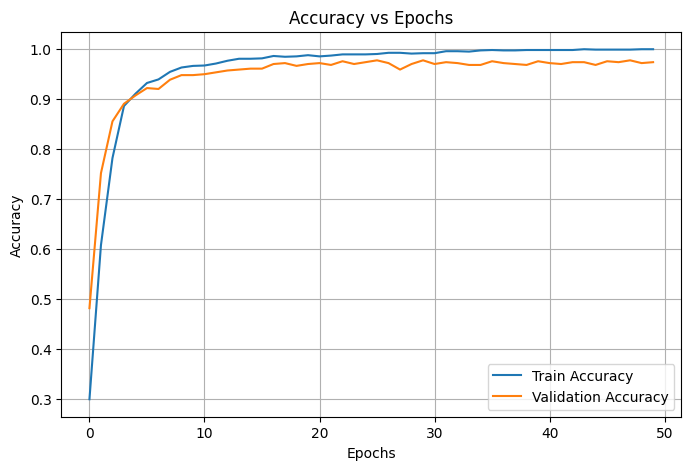

In [10]:
# ==============================
# Plot Accuracy Graph
# ==============================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

# <font color="Blue">**Loss Graph:**


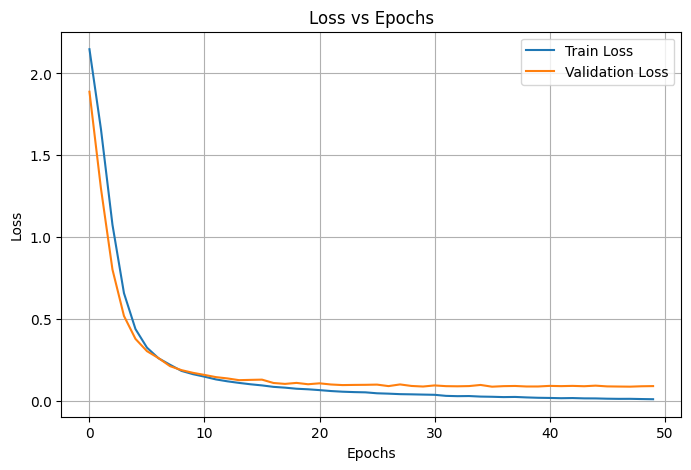

In [11]:
# ==============================
# Plot Loss Graph
# ==============================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

# <font color="Blue">**Evaluate Basic Model:**


In [13]:
# ==============================
# Evaluate Basic Model
# ==============================

test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"Basic Model Test Accuracy: {test_acc:.4f}")
print(f"Basic Model Test Loss: {test_loss:.4f}")

Basic Model Test Accuracy: 0.9741
Basic Model Test Loss: 0.0920


# <font color="Blue">**Classification Report:**


In [14]:
# ==============================
# Classification Report
# ==============================

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report (Basic Model):")

print(classification_report(y_test, y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Classification Report (Basic Model):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.94      1.00      0.97        50
           2       0.96      1.00      0.98        47
           3       1.00      0.96      0.98        54
           4       1.00      0.98      0.99        60
           5       0.97      0.94      0.95        66
           6       0.98      0.98      0.98        53
           7       0.96      0.98      0.97        55
           8       0.95      0.95      0.95        43
           9       0.98      0.97      0.97        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



# <font color="Blue">**Modified ANN Model:**


In [15]:
# ==============================
# 7. Modified ANN Model
# ==============================

model_v2 = Sequential([
    Input(shape=(64,)),

    Dense(128, activation='tanh'),

    Dense(64, activation='tanh'),

    Dense(32, activation='relu'),

    Dense(10, activation='softmax')
])

model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,986 (74.16 KB)

 Trainable params: 18,986 (74.16 KB)

 Non-trainable params: 0 (0.00 B)

# <font color="Blue">**Compile & Train Modified Model:**


In [ ]:
# ==============================
# Compile Modified Model
# ==============================

model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Train Modified Model
# ==============================

history_v2 = model_v2.fit(
    X_train,
    y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

# <font color="Blue">**Evaluate Modified Model:**


In [24]:
# ==============================
# Evaluate Modified Model
# ==============================

v2_loss, v2_acc = model_v2.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"\nVaried Model Test Accuracy: {v2_acc:.4f}")


Varied Model Test Accuracy: 0.9815


# <font color="Blue">**Compare Model Performance:**


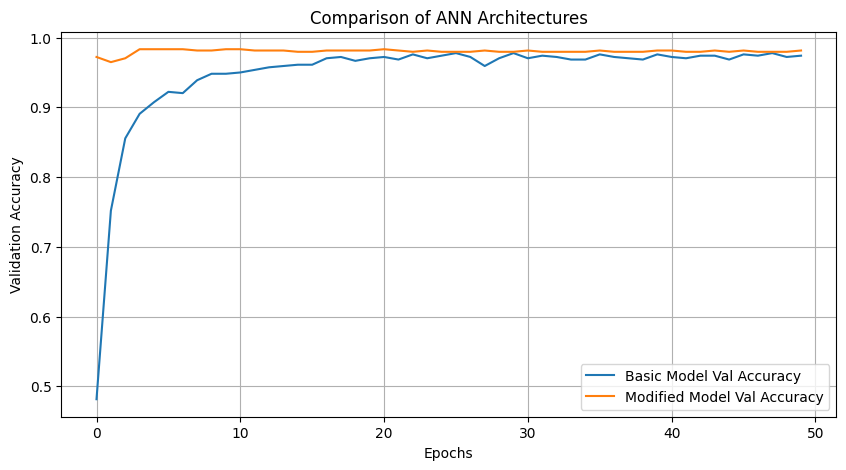

In [25]:
# ==============================
# Compare Model Performance
# ==============================

plt.figure(figsize=(10,5))

plt.plot(history.history['val_accuracy'],
         label='Basic Model Val Accuracy')

plt.plot(history_v2.history['val_accuracy'],
         label='Modified Model Val Accuracy')

plt.title("Comparison of ANN Architectures")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

# <font color="Blue">**Regularized ANN Model:**


In [26]:
# ==============================
# 8. Regularized ANN Model
# ==============================

reg_model = Sequential([
    Input(shape=(64,)),

    Dense(
        128,
        activation='relu',
        kernel_regularizer=l2(0.01)
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu',
        kernel_regularizer=l2(0.01)
    ),

    Dropout(0.2),

    Dense(10, activation='softmax')
])

reg_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

# <font color="Blue">**Compile & Train Regularized Model:**


In [27]:
# ==============================
# Compile Regularized Model
# ==============================

reg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Train Regularized Model
# ==============================

history_reg = reg_model.fit(
    X_train,
    y_train_cat,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    verbose=0
)

# <font color="Blue">**Final Evaluation:**


In [28]:
# ==============================
# Final Evaluation
# ==============================

y_pred = np.argmax(
    reg_model.predict(X_test),
    axis=1
)

print("Accuracy Score:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy Score: 0.9685185185185186

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        53
           1       0.96      1.00      0.98        50
           2       0.98      1.00      0.99        47
           3       0.98      0.94      0.96        54
           4       0.97      1.00      0.98        60
           5       0.94      0.97      0.96        66
           6       0.98      0.98      0.98        53
           7       0.96      0.98      0.97        55
           8       0.95      0.93      0.94        43
           9       0.98      0.92      0.95        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



# <font color="Blue">**Confusion Matrix:**


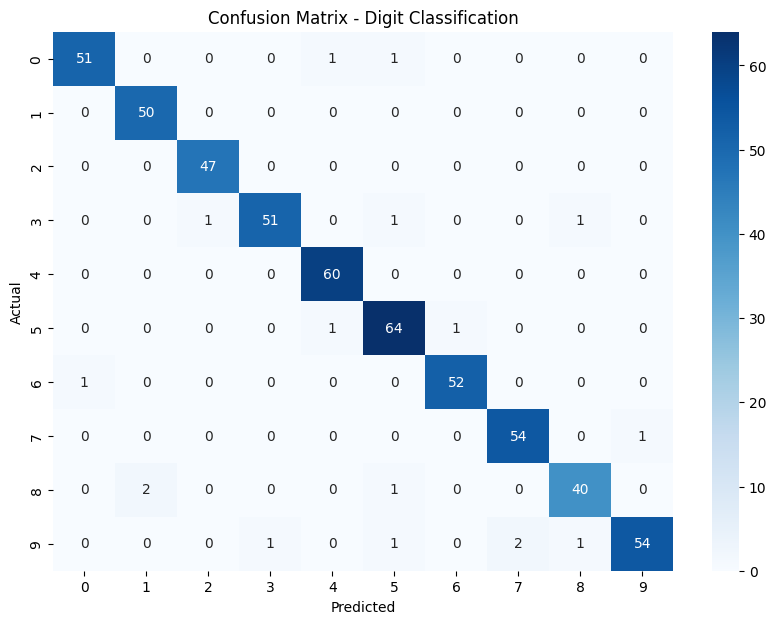

In [29]:
# ==============================
# Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix - Digit Classification')

plt.show()

## <font color="Blue">**Summerize the observations:**

* ANN successfully classified handwritten digits.
* Increasing hidden layers and neurons improved performance.
* Different activation functions affected convergence speed and accuracy.
* Regularization techniques such as Dropout and L2 helped reduce overfitting.
* Validation accuracy remained close to training accuracy, indicating good generalization.
* Final ANN model achieved high classification accuracy.

